# Task 1 — Iron Gate HPP: Linear Inflow → Production Model

## Task 1.a — Linear Production Model

In [1]:
import os
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

os.makedirs("figures", exist_ok=True)

### Load data

In [2]:
df = pl.read_excel("data/Hydro.xlsx")
df = df.with_columns(pl.col("Date").cast(pl.Date)).sort("Date")  # cast ensures date, not string sort
df.head(10)

Date,River Flow [m^3/s],Production [MWh/daily]
date,f64,i64
2015-02-12,7100.0,19802
2015-02-13,6800.0,20336
2015-02-14,6700.0,18313
2015-02-15,6600.0,17703
2015-02-16,6500.0,18396
2015-02-17,6300.0,17602
2015-02-18,6150.0,17224
2015-02-19,6150.0,17719
2015-02-20,6000.0,17217


### Fit linear model

In [3]:
df_no_nan = df.drop_nulls() # Remove rows with NaN values
flow_col = 'River Flow [m^3/s]'
production_col = 'Production [MWh/daily]'
X = df_no_nan[flow_col].to_numpy().reshape(-1, 1)
y = df_no_nan[production_col].to_numpy()

model = LinearRegression()
model.fit(X, y)

k = model.coef_[0]
n = model.intercept_
r2 = model.score(X, y)

print("=" * 45)
print("Linear Model:  y = k·x + n")
print("=" * 45)
print(f"k (slope)     = {k:.6f}  [MWh/day per m³/s]")
print(f"n (intercept) = {n:.4f}  [MWh/day]")
print(f"R²            = {r2:.6f}")

Linear Model:  y = k·x + n
k (slope)     = 2.484068  [MWh/day per m³/s]
n (intercept) = 1935.0854  [MWh/day]
R²            = 0.913465


### Predict

In [4]:
inflows = [4000, 11000] # m³/s

print("=" * 50)
print("Predictions")
print("=" * 50)
for q in inflows:
    y_pred = model.predict([[q]])[0]
    print(f"  Q = {q:>6} m³/s  →  Production = {y_pred:>10.2f} MWh/day")

Predictions
  Q =   4000 m³/s  →  Production =   11871.36 MWh/day
  Q =  11000 m³/s  →  Production =   29259.83 MWh/day


### Visualise

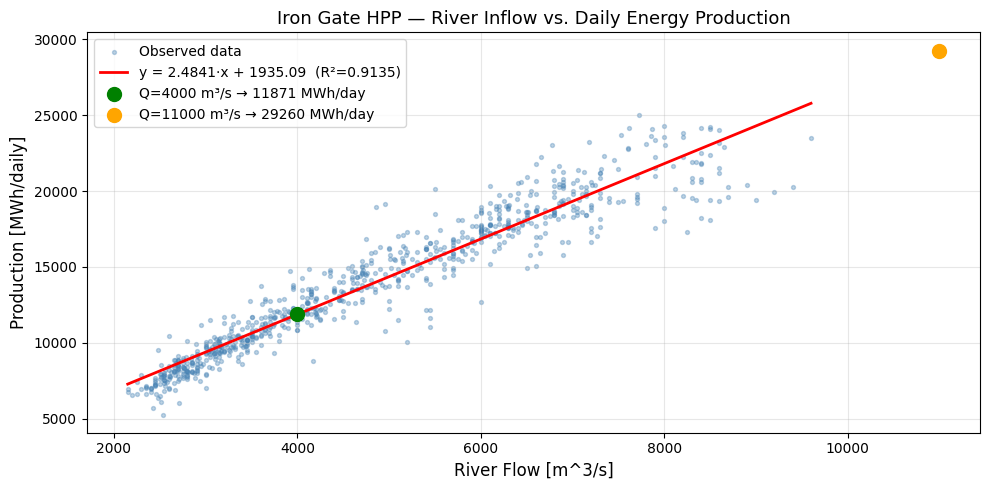

In [5]:
x_line = np.linspace(X.min(), X.max(), 300)
y_line = model.predict(x_line.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(X, y, s=8, alpha=0.35, color="steelblue", label="Observed data")
ax.plot(x_line, y_line, color="red", linewidth=2,
        label=f"y = {k:.4f}·x + {n:.2f}  (R²={r2:.4f})")

colors = {4000: "green", 11000: "orange"}
for q, color in colors.items():
    y_pred = model.predict([[q]])[0]
    ax.scatter([q], [y_pred], s=100, color=color, zorder=6,
               label=f"Q={q} m³/s → {y_pred:.0f} MWh/day")

ax.set_xlabel(flow_col, fontsize=12)
ax.set_ylabel(production_col, fontsize=12)
ax.set_title("Iron Gate HPP — River Inflow vs. Daily Energy Production", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/task_1a_linear_model.png", dpi=150)
plt.show()

---

## Task 1.b — Non-linear Models with Train/Test Split

In [6]:
import pandas as pd
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from autogluon.tabular.experimental import TabularRegressor

/home/petelin/gen-i-task/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Train / test split

In [7]:
df_clean = df.drop_nulls()
split = int(len(df_clean) * 0.8)

X_all = df_clean[flow_col].to_numpy().reshape(-1, 1)
y_all = df_clean[production_col].to_numpy()
dates_all = df_clean["Date"].to_numpy()

X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]
dates_test = dates_all[split:]

print(f"Total samples : {len(df_clean)}")
print(f"Train / Test  : {len(X_train)} / {len(X_test)}")

Total samples : 819
Train / Test  : 655 / 164


### Fit models

All three models are trained on the training set only.

In [8]:
linear = LinearRegression()
linear.fit(X_train, y_train)

spline = Pipeline([
    ("spline", SplineTransformer(n_knots=8, degree=3, include_bias=False)),
    ("lr",     LinearRegression()),
])
spline.fit(X_train, y_train)

autogluon = TabularRegressor(verbosity=0)
autogluon.fit(X_train, y_train)

models = {"Linear": linear, "Spline": spline, "AutoGluon": autogluon}
print("All models fitted.")

/home/petelin/gen-i-task/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
/home/petelin/gen-i-task/.venv/lib/python3.13/site-packages/sklearn/compose/_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


All models fitted.


### Evaluate on test set

In [9]:
print(f"{'Model':<15} {'RMSE':>10} {'MAE':>10} {'R²':>8}")
print("-" * 47)

results = {}
for name, mdl in models.items():
    y_pred = mdl.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    results[name] = y_pred
    print(f"{name:<15} {rmse:>10.1f} {mae:>10.1f} {r2:>8.4f}")

Model                 RMSE        MAE       R²
-----------------------------------------------
Linear              1011.6      781.3   0.9073
Spline               938.2      725.3   0.9202
AutoGluon            887.0      693.3   0.9287


### Actual vs predicted — test set

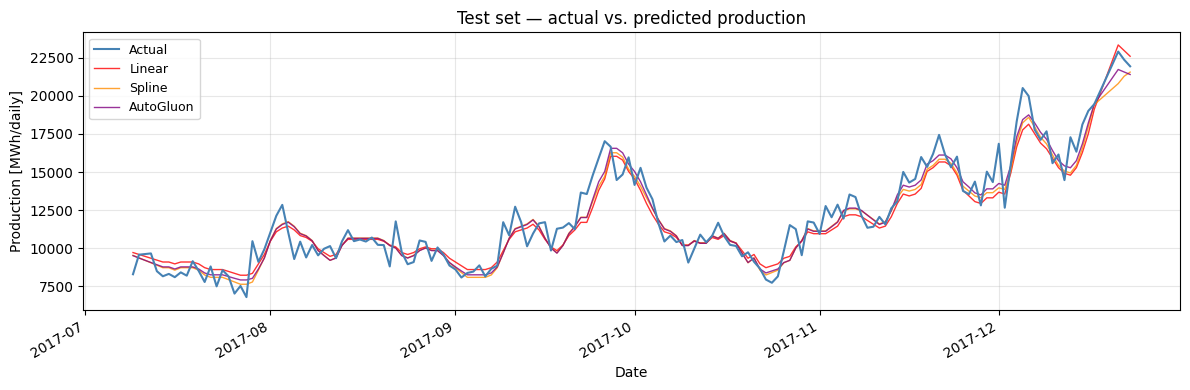

In [10]:
colors_m = {"Linear": "red", "Spline": "darkorange", "AutoGluon": "purple"}

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(dates_test, y_test, color="steelblue", linewidth=1.5, label="Actual", zorder=5)
for name, y_pred in results.items():
    ax.plot(dates_test, y_pred, color=colors_m[name], linewidth=1, alpha=0.8, label=name)

ax.set_xlabel("Date")
ax.set_ylabel(production_col)
ax.set_title("Test set — actual vs. predicted production")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("figures/task_1b_timeseries.png", dpi=150)
plt.show()

### Model curves

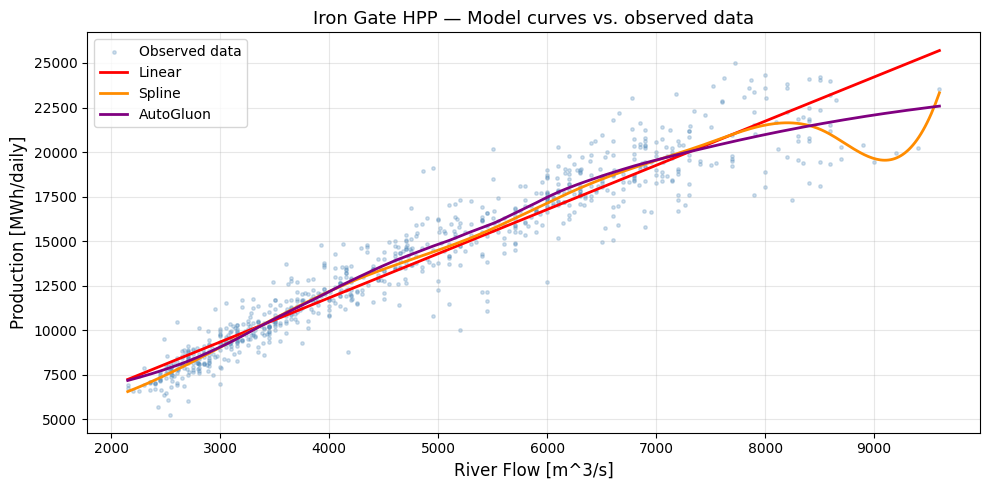

In [11]:
x_line = np.linspace(X_all.min(), X_all.max(), 400).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(X_all, y_all, s=6, alpha=0.25, color="steelblue", label="Observed data")

for name, mdl in models.items():
    ax.plot(x_line, mdl.predict(x_line), color=colors_m[name], linewidth=2, label=name)

ax.set_xlabel(flow_col, fontsize=12)
ax.set_ylabel(production_col, fontsize=12)
ax.set_title("Iron Gate HPP — Model curves vs. observed data", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/task_1b_model_curves.png", dpi=150)
plt.show()

---

## Task 1.c — Daily Forecasting Process

*(see README)*

---

## Task 1.d — Factors Influencing Electricity Prices

*(see README)*